## Figure 5: MSA and peptide mapping ##

Scripts use 

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from scipy.stats import ttest_ind
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date
from statsmodels.stats.weightstats import ztest as ztest
import scikit_posthocs as sph

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

In [3]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV2_3,DCX_DIV2_1,DCX_DIV2_2,DCX_DIV3_2,DCX_DIV3_3,DCX_DIV3_1,DCX_DIV4_2,DCX_DIV4_3,DCX_DIV4_1,DCX_DIV5_3,...,Valid values DCX_DIV5,Valid values R178L_DIV5,Protein.Group,Protein.Ids,Genes,Stripped.Sequence,Modified.Sequence,Precursor.Id,DomSpec,IsoSpec
0,13.798695,14.341526,14.590377,13.823706,13.501352,14.137407,15.317207,14.963118,14.645827,13.363409,...,4,4,Q3KQU3,Q3KQU3,MAP7D1,AELGAGAPPAVVAR,AELGAGAPPAVVAR,AELGAGAPPAVVAR2,N-Term,Skipped
1,12.029898,13.102294,11.515296,9.872943,NaN,NaN,12.892493,12.696698,12.203094,11.528654,...,4,4,Q3KQU3,Q3KQU3,MAP7D1,AQAEQEEQER,AQAEQEEQER,AQAEQEEQER2,Internal,Conserved
2,10.630249,NaN,NaN,NaN,NaN,NaN,11.571596,12.149087,NaN,11.656366,...,2,3,Q3KQU3,Q3KQU3,MAP7D1,AVVQSPQVTEVL,AVVQSPQVTEVL,AVVQSPQVTEVL2,C-Term,Conserved
3,NaN,10.391985,NaN,NaN,NaN,NaN,NaN,10.239431,NaN,14.074200,...,4,3,Q3KQU3,Q3KQU3,MAP7D1,EAVQKEEPIPQEPQWSLPSK,EAVQKEEPIPQEPQWSLPSK,EAVQKEEPIPQEPQWSLPSK3,C-Term,Conserved
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.065976,11.103930,NaN,...,2,1,Q3KQU3,Q3KQU3,MAP7D1,EKHFQQQEQER,EKHFQQQEQER,EKHFQQQEQER2,C-Term,Conserved
5,14.578744,14.979988,15.239703,NaN,NaN,13.481459,15.580450,14.493843,15.138344,13.968369,...,4,4,Q3KQU3,Q3KQU3,MAP7D1,ESPSAAGPEDK,ESPSAAGPEDK,ESPSAAGPEDK2,Internal,Conserved
6,10.868406,NaN,NaN,NaN,NaN,NaN,NaN,11.542312,10.510082,9.599587,...,3,1,Q3KQU3,Q3KQU3,MAP7D1,HFQQQEQER,HFQQQEQER,HFQQQEQER2,C-Term,Conserved
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640431,...,3,2,Q3KQU3,Q3KQU3,MAP7D1,LMTPTLSFLAR,LM(UniMod:35)TPTLSFLAR,LM(UniMod:35)TPTLSFLAR2,Internal,Canonical
8,NaN,NaN,13.019615,12.415340,12.345954,12.755590,14.430571,13.704152,12.954227,NaN,...,1,2,Q3KQU3,Q3KQU3,MAP7D1,LSASTASELSPK,LSASTASELSPK,LSASTASELSPK2,Junction,Conserved
9,13.026814,13.849972,NaN,NaN,NaN,14.269974,14.464705,14.035478,NaN,NaN,...,1,3,Q3KQU3,Q3KQU3,MAP7D1,PAPPQEESPSSEAK,PAPPQEESPSSEAK,PAPPQEESPSSEAK2,N-Term,Canonical


## Multiple-sequence alignment ##

Running script will prompt the manual insertion of proteins (with isoform designators) followed by isoform sequences. Requires at least 2 sequences.

In [5]:
"""
Interactive protein-sequence input and multiple alignment.

Run this block before the peptide coverage-map script. It creates the
ALIGNED_SEQUENCES dictionary expected by that script.

This dependency-free centre-star aligner is intended for closely related
proteins and isoforms. For divergent proteins, use MAFFT, MUSCLE, or Clustal
Omega and import their aligned FASTA output instead.
"""

import re
import tkinter as tk
from tkinter import messagebox, simpledialog


# Simple protein global-alignment scores. These work well for related isoforms.
MATCH_SCORE = 2
MISMATCH_SCORE = -1
GAP_SCORE = -2


def clean_protein_sequence(text):
    """Remove a FASTA header, whitespace, numbers, and punctuation."""
    lines = str(text).strip().splitlines()
    sequence_lines = [line for line in lines if not line.lstrip().startswith(">")]
    return re.sub(r"[^A-Za-z]", "", "".join(sequence_lines)).upper()


def parse_fasta(text):
    """Parse two or more FASTA records into a name-to-sequence dictionary."""
    records = {}
    current_name = None
    current_lines = []

    def save_current_record():
        if current_name is None:
            return
        sequence = clean_protein_sequence("\n".join(current_lines))
        if not sequence:
            raise ValueError(f'No sequence was supplied for "{current_name}".')
        if current_name in records:
            raise ValueError(f'Duplicate protein name: "{current_name}".')
        records[current_name] = sequence

    for raw_line in str(text).splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith(">"):
            save_current_record()
            current_name = line[1:].strip()
            if not current_name:
                raise ValueError("Every FASTA header needs a protein name after >.")
            current_lines = []
        else:
            if current_name is None:
                raise ValueError("FASTA input must begin with a header such as >Protein 1.")
            current_lines.append(line)

    save_current_record()
    if len(records) < 2:
        raise ValueError("Please supply at least two FASTA protein records.")
    return records


def global_align(sequence_a, sequence_b):
    """Needleman-Wunsch global alignment with deterministic traceback."""
    rows = len(sequence_a) + 1
    columns = len(sequence_b) + 1
    scores = [[0] * columns for _ in range(rows)]
    traceback = [[""] * columns for _ in range(rows)]

    for row in range(1, rows):
        scores[row][0] = row * GAP_SCORE
        traceback[row][0] = "up"
    for column in range(1, columns):
        scores[0][column] = column * GAP_SCORE
        traceback[0][column] = "left"

    for row in range(1, rows):
        residue_a = sequence_a[row - 1]
        for column in range(1, columns):
            residue_b = sequence_b[column - 1]
            diagonal = scores[row - 1][column - 1] + (
                MATCH_SCORE if residue_a == residue_b else MISMATCH_SCORE
            )
            up = scores[row - 1][column] + GAP_SCORE
            left = scores[row][column - 1] + GAP_SCORE
            best = max(diagonal, up, left)
            scores[row][column] = best
            # Prefer residue-to-residue alignment when scores tie.
            traceback[row][column] = (
                "diagonal" if diagonal == best else "up" if up == best else "left"
            )

    aligned_a = []
    aligned_b = []
    row, column = len(sequence_a), len(sequence_b)
    while row > 0 or column > 0:
        direction = traceback[row][column]
        if direction == "diagonal":
            aligned_a.append(sequence_a[row - 1])
            aligned_b.append(sequence_b[column - 1])
            row -= 1
            column -= 1
        elif direction == "up":
            aligned_a.append(sequence_a[row - 1])
            aligned_b.append("-")
            row -= 1
        else:
            aligned_a.append("-")
            aligned_b.append(sequence_b[column - 1])
            column -= 1

    return "".join(reversed(aligned_a)), "".join(reversed(aligned_b))


def split_against_reference(aligned_reference, aligned_sequence, reference_length):
    """Represent a pairwise alignment as insertions and reference residues."""
    insertions = [""] * (reference_length + 1)
    residues = ["-"] * reference_length
    reference_index = 0

    for reference_character, sequence_character in zip(
        aligned_reference, aligned_sequence
    ):
        if reference_character == "-":
            insertions[reference_index] += sequence_character
        else:
            residues[reference_index] = sequence_character
            reference_index += 1

    if reference_index != reference_length:
        raise RuntimeError("Internal alignment-coordinate error.")
    return insertions, residues


def centre_star_alignment(named_sequences):
    """Align every protein to the longest sequence and merge shared columns."""
    if not named_sequences:
        return {}

    reference_name = max(named_sequences, key=lambda name: len(named_sequences[name]))
    reference = named_sequences[reference_name]
    reference_length = len(reference)
    decomposed = {}

    for name, sequence in named_sequences.items():
        if name == reference_name:
            aligned_reference, aligned_sequence = reference, reference
        else:
            aligned_reference, aligned_sequence = global_align(reference, sequence)
        decomposed[name] = split_against_reference(
            aligned_reference, aligned_sequence, reference_length
        )

    maximum_insertions = [
        max(len(decomposed[name][0][slot]) for name in named_sequences)
        for slot in range(reference_length + 1)
    ]

    aligned_sequences = {}
    for name in named_sequences:
        insertions, residues = decomposed[name]
        pieces = []
        for slot in range(reference_length + 1):
            pieces.append(insertions[slot])
            pieces.append("-" * (maximum_insertions[slot] - len(insertions[slot])))
            if slot < reference_length:
                pieces.append(residues[slot])
        aligned_sequences[name] = "".join(pieces)

    lengths = {len(sequence) for sequence in aligned_sequences.values()}
    if len(lengths) != 1:
        raise RuntimeError("Alignment failed to produce equal-length sequences.")
    return aligned_sequences


def paste_sequence_dialog(root, protein_number, default_name):
    """Display a multiline dialog and return (name, sequence), or None."""
    result = {"value": None}
    window = tk.Toplevel(root)
    window.title(f"Protein {protein_number}")
    window.geometry("680x430")

    # The root window is deliberately hidden. Making this dialog transient to
    # that hidden root can place it behind Spyder/Jupyter on Windows, so keep it
    # as an independent top-level window and explicitly bring it forward.
    window.attributes("-topmost", True)

    tk.Label(window, text="Protein name:").pack(anchor="w", padx=12, pady=(12, 2))
    name_entry = tk.Entry(window)
    name_entry.insert(0, default_name)
    name_entry.pack(fill="x", padx=12)

    tk.Label(
        window,
        text="Paste the protein sequence (plain text or FASTA):",
    ).pack(anchor="w", padx=12, pady=(12, 2))
    sequence_text = tk.Text(window, wrap="word", font=("Consolas", 10))
    sequence_text.pack(fill="both", expand=True, padx=12, pady=(0, 10))

    def accept():
        name = name_entry.get().strip()
        sequence = clean_protein_sequence(sequence_text.get("1.0", "end"))
        if not name:
            messagebox.showerror("Missing name", "Enter a name for this protein.", parent=window)
            return
        if not sequence:
            messagebox.showerror("Missing sequence", "Paste a protein sequence.", parent=window)
            return
        result["value"] = (name, sequence)
        window.destroy()

    def cancel():
        window.destroy()

    button_frame = tk.Frame(window)
    button_frame.pack(fill="x", padx=12, pady=(0, 12))
    tk.Button(button_frame, text="Cancel", command=cancel).pack(side="right")
    tk.Button(button_frame, text="Use sequence", command=accept).pack(side="right", padx=8)
    window.protocol("WM_DELETE_WINDOW", cancel)
    window.update_idletasks()

    # Centre the dialog on screen.
    width = window.winfo_width()
    height = window.winfo_height()
    x_position = max(0, (window.winfo_screenwidth() - width) // 2)
    y_position = max(0, (window.winfo_screenheight() - height) // 2)
    window.geometry(f"{width}x{height}+{x_position}+{y_position}")

    window.deiconify()
    window.lift()
    window.focus_force()
    window.grab_set()
    name_entry.focus_set()

    # Topmost is needed only long enough to surface the window; leaving it on
    # permanently would make other applications awkward to use.
    window.after(750, lambda: window.attributes("-topmost", False))
    root.wait_window(window)
    return result["value"]


def prompt_for_and_align_sequences():
    """Collect proteins in GUI dialogs, align them, and return a dictionary."""
    root = tk.Tk()
    root.withdraw()
    try:
        count = simpledialog.askinteger(
            "Protein sequences",
            "How many protein sequences do you want to align?",
            parent=root,
            minvalue=2,
        )
        if count is None:
            raise SystemExit("Sequence entry was cancelled.")

        named_sequences = {}
        for number in range(1, count + 1):
            entry = paste_sequence_dialog(root, number, f"Protein {number}")
            if entry is None:
                raise SystemExit("Sequence entry was cancelled.")
            name, sequence = entry
            if name in named_sequences:
                messagebox.showerror(
                    "Duplicate name",
                    f'The name "{name}" was already used. Please run the block again.',
                    parent=root,
                )
                raise ValueError(f"Duplicate protein name: {name}")
            named_sequences[name] = sequence

        aligned = centre_star_alignment(named_sequences)
        aligned_length = len(next(iter(aligned.values())))
        messagebox.showinfo(
            "Alignment complete",
            f"Aligned {len(aligned)} proteins across {aligned_length} columns.",
            parent=root,
        )
        return aligned
    finally:
        root.destroy()


def running_in_jupyter():
    """Return True for a Jupyter/IPython kernel and False for a normal script."""
    try:
        shell_name = get_ipython().__class__.__name__
        return shell_name == "ZMQInteractiveShell"
    except NameError:
        return False


def show_jupyter_alignment_form():
    """Display an in-notebook FASTA form and update ALIGNED_SEQUENCES."""
    try:
        import ipywidgets as widgets
        from IPython.display import display
    except ImportError as error:
        raise ImportError(
            "This Jupyter interface requires ipywidgets. Install it with "
            "`pip install ipywidgets`, then restart the kernel."
        ) from error

    instructions = widgets.HTML(
        "<b>Paste all protein sequences in FASTA format</b><br>"
        "Each sequence must begin with a line such as <code>&gt;EML4 isoform 1</code>."
    )
    fasta_box = widgets.Textarea(
        placeholder=(
            ">Protein 1\nMAAA...\n"
            ">Protein 2\nMAAA..."
        ),
        layout=widgets.Layout(width="100%", height="300px"),
    )
    align_button = widgets.Button(
        description="Align sequences",
        button_style="primary",
        icon="check",
    )
    output = widgets.Output()

    def align_from_box(_button):
        with output:
            output.clear_output()
            try:
                named_sequences = parse_fasta(fasta_box.value)
                aligned = centre_star_alignment(named_sequences)
                ALIGNED_SEQUENCES.clear()
                ALIGNED_SEQUENCES.update(aligned)
                aligned_length = len(next(iter(aligned.values())))
                print(
                    f"Alignment complete: {len(aligned)} proteins, "
                    f"{aligned_length} aligned columns."
                )
                print("\nAligned protein sequences:")
                for protein_name, aligned_sequence in aligned.items():
                    print(f">{protein_name}\n{aligned_sequence}")
                print("\nALIGNED_SEQUENCES is ready. Run the coverage-map cell next.")
            except Exception as error:
                print(f"Could not align the sequences: {error}")

    align_button.on_click(align_from_box)
    display(widgets.VBox([instructions, fasta_box, align_button, output]))


# This is the variable consumed by the peptide coverage-map script.
ALIGNED_SEQUENCES = {}


if running_in_jupyter():
    show_jupyter_alignment_form()
else:
    ALIGNED_SEQUENCES.update(prompt_for_and_align_sequences())
    print("\nAligned protein sequences:")
    for protein_name, aligned_sequence in ALIGNED_SEQUENCES.items():
        print(f">{protein_name}\n{aligned_sequence}")


## Peptide mapping script ##

Running this script after MSA maps does the following:

1. maps peptides to isoforms individually
2. calculates % sequence coverage for each form
3. shows overlapping peptides (includes legend to decipher overlap) and generates a summary of peptide depth
4. determines whether peptides remain unmapped

Unique peptide sequences loaded: 14
Aligned sequence length: 841 columns


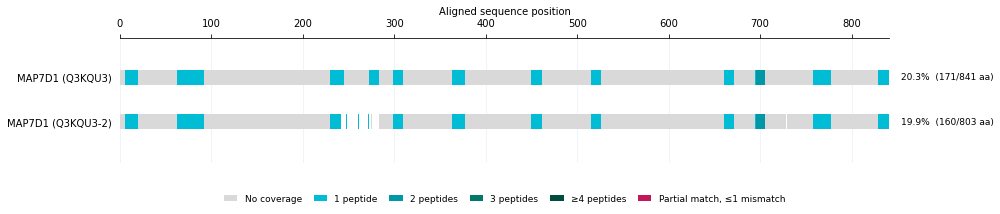


Sequence coverage summary:
         Template  Protein.Length.aa  Reported.Covered.Residues  Sequence.Coverage.Percent  Maximum.Exact.Peptide.Depth  Unique.Exact.Peptides  Unique.Partial.Peptides
  MAP7D1 (Q3KQU3)                841                        171                  20.332937                            2                     14                        0
MAP7D1 (Q3KQU3-2)                803                        160                  19.925280                            2                     13                        0

Files saved:
SVG:      C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Peptides\Peptide_Coverage_Maps\MAPT_Peptide_Coverage_Map.svg
PNG:      C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Peptides\Peptide_Coverage_Maps\MAPT_Peptide_Coverage_Map.png
Summary:  C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Peptides\Peptide_Coverage_Maps\MAPT_Peptide_Covera

In [6]:
# ============================================================
# PEPTIDE COVERAGE MAP
# Run this block AFTER:
#
# Pre-alignment script!
# ============================================================

import os
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import to_rgb


# ============================================================
# 1. USER SETTINGS
# ============================================================

PEPTIDE_COLUMN = "Stripped.Sequence"

OUTPUT_FOLDER_NAME = "Peptide_Coverage_Maps"
OUTPUT_BASENAME = "MAPT_Peptide_Coverage_Map"

# Approximate matching:
# A "partial match" here means a peptide of the same length that differs
# from the template at no more than MAX_MISMATCHES amino-acid positions.
ALLOW_PARTIAL_MATCHES = True
MAX_MISMATCHES = 1
MIN_PARTIAL_PEPTIDE_LENGTH = 7

# Conservative default:
# Approximate matches are displayed in magenta but are NOT included in
# the reported sequence-coverage percentage.
INCLUDE_PARTIAL_IN_COVERAGE = False

# Image settings
PNG_DPI = 600
FIGURE_WIDTH = 14
ROW_HEIGHT = 0.65
ROD_HEIGHT = 0.34

# Discrete peptide-depth colours
NO_COVERAGE_COLOR = "#D9D9D9"
DEPTH_1_COLOR = "#00BCD4"       # cyan
DEPTH_2_COLOR = "#0097A7"       # teal
DEPTH_3_COLOR = "#00796B"       # deeper teal
DEPTH_4_PLUS_COLOR = "#004D40"  # darkest teal
PARTIAL_MATCH_COLOR = "#C2185B" # magenta

# Alignment gaps are left blank
GAP_CHARACTER = "-"


# ============================================================
# 2. PASTE ALIGNED TEMPLATE SEQUENCES HERE
# ============================================================
#
# IMPORTANT:
# All sequences must have the SAME aligned length.
#
# Use "-" characters to represent alignment gaps.
# Spaces and line breaks are removed automatically.
#
# Peptides are matched against the corresponding ungapped sequence,
# then mapped back into aligned coordinates.
#
# Example:
#
# "EML4 isoform 1": "MAAA---AAAA...",
# "Eml4 long":      "MAAAGGGAAAA...",
# "Eml4 short":     "MAAA------A...",
#

# ALIGNED_SEQUENCES = {

#     "EML4 isoform 1": """
#     PASTE_ALIGNED_SEQUENCE_HERE
#     """,

#     "Eml4 long": """
#     PASTE_ALIGNED_SEQUENCE_HERE
#     """,

#     "Eml4 short": """
#     PASTE_ALIGNED_SEQUENCE_HERE
#     """,
# }


# # ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def clean_template_sequence(sequence):
    """
    Retain amino-acid letters and alignment gap characters.
    Remove spaces, numbers, line breaks, FASTA symbols, and punctuation.
    """
    sequence = str(sequence).upper()
    sequence = re.sub(rf"[^A-Z{re.escape(GAP_CHARACTER)}]", "", sequence)
    return sequence


def clean_peptide_sequence(peptide):
    """
    Keep uppercase amino-acid letters only.

    Because the source column is Stripped.Sequence, this will ordinarily
    leave the peptide unchanged while removing accidental whitespace or
    punctuation.
    """
    if pd.isna(peptide):
        return ""

    peptide = str(peptide).upper().strip()
    peptide = re.sub(r"[^A-Z]", "", peptide)

    return peptide


def make_alignment_coordinate_map(aligned_sequence):
    """
    Create:
      1. ungapped sequence used for peptide searching;
      2. a map from ungapped residue index to aligned column index.
    """
    ungapped_sequence = []
    ungapped_to_aligned = []

    for aligned_index, residue in enumerate(aligned_sequence):
        if residue != GAP_CHARACTER:
            ungapped_sequence.append(residue)
            ungapped_to_aligned.append(aligned_index)

    return "".join(ungapped_sequence), np.array(ungapped_to_aligned, dtype=int)


def find_all_exact_matches(sequence, peptide):
    """
    Return all start positions at which peptide occurs exactly in sequence.
    Overlapping occurrences are included.
    """
    starts = []
    search_start = 0

    while True:
        match_start = sequence.find(peptide, search_start)

        if match_start == -1:
            break

        starts.append(match_start)
        search_start = match_start + 1

    return starts


def mismatch_count(sequence_window, peptide):
    """
    Count amino-acid substitutions between two equal-length strings.
    """
    return sum(a != b for a, b in zip(sequence_window, peptide))


def find_best_partial_matches(
    sequence,
    peptide,
    max_mismatches=1,
    minimum_length=7
):
    """
    Find same-length windows differing by no more than max_mismatches.

    Only the best mismatch class is returned. For example, if the best
    windows have one mismatch, all one-mismatch windows are returned.
    """
    if len(peptide) < minimum_length:
        return []

    if len(peptide) > len(sequence):
        return []

    candidate_matches = []
    best_mismatch_number = max_mismatches + 1

    final_start = len(sequence) - len(peptide)

    for start in range(final_start + 1):
        sequence_window = sequence[start:start + len(peptide)]
        mismatches = mismatch_count(sequence_window, peptide)

        if mismatches > max_mismatches:
            continue

        if mismatches < best_mismatch_number:
            best_mismatch_number = mismatches
            candidate_matches = [(start, mismatches)]

        elif mismatches == best_mismatch_number:
            candidate_matches.append((start, mismatches))

    return candidate_matches


def depth_to_color(depth):
    """
    Convert exact peptide depth into a discrete colour.
    """
    if depth <= 0:
        return NO_COVERAGE_COLOR
    elif depth == 1:
        return DEPTH_1_COLOR
    elif depth == 2:
        return DEPTH_2_COLOR
    elif depth == 3:
        return DEPTH_3_COLOR
    else:
        return DEPTH_4_PLUS_COLOR


def luminance(hex_color):
    """
    Estimate perceived luminance, useful for checking colours if needed.
    """
    red, green, blue = to_rgb(hex_color)
    return 0.2126 * red + 0.7152 * green + 0.0722 * blue


def run_length_segments(values):
    """
    Convert an array into contiguous runs of identical values.

    Returns:
        [(start, end_exclusive, value), ...]
    """
    values = np.asarray(values)

    if len(values) == 0:
        return []

    segments = []
    segment_start = 0
    current_value = values[0]

    for index in range(1, len(values)):
        if values[index] != current_value:
            segments.append((segment_start, index, current_value))
            segment_start = index
            current_value = values[index]

    segments.append((segment_start, len(values), current_value))

    return segments


# ============================================================
# 4. VALIDATE AND CLEAN INPUT
# ============================================================

if PEPTIDE_COLUMN not in data.columns:
    raise KeyError(
        f'Column "{PEPTIDE_COLUMN}" was not found.\n\n'
        f"Available columns are:\n{list(data.columns)}"
    )

if not ALIGNED_SEQUENCES:
    raise ValueError("No template sequences were supplied.")

cleaned_aligned_sequences = {
    name: clean_template_sequence(sequence)
    for name, sequence in ALIGNED_SEQUENCES.items()
}

# Catch unchanged placeholders
placeholder_templates = [
    name
    for name, sequence in cleaned_aligned_sequences.items()
    if "PASTEALIGNEDSEQUENCEHERE" in sequence
]

if placeholder_templates:
    raise ValueError(
        "Replace the placeholder sequence for:\n"
        + "\n".join(f"  - {name}" for name in placeholder_templates)
    )

# Confirm all sequences are aligned to the same total length
alignment_lengths = {
    name: len(sequence)
    for name, sequence in cleaned_aligned_sequences.items()
}

unique_alignment_lengths = set(alignment_lengths.values())

if len(unique_alignment_lengths) != 1:
    length_report = "\n".join(
        f"  {name}: {length} aligned positions"
        for name, length in alignment_lengths.items()
    )

    raise ValueError(
        "All template sequences must have the same aligned length.\n\n"
        f"{length_report}\n\n"
        'Add "-" characters to represent alignment gaps.'
    )

alignment_length = next(iter(unique_alignment_lengths))

# Clean peptides and remove duplicates
peptides = (
    data[PEPTIDE_COLUMN]
    .dropna()
    .map(clean_peptide_sequence)
)

peptides = peptides[peptides != ""]
peptides = peptides.drop_duplicates().tolist()

if len(peptides) == 0:
    raise ValueError(
        f'No usable peptide sequences were found in "{PEPTIDE_COLUMN}".'
    )

print(f"Unique peptide sequences loaded: {len(peptides)}")
print(f"Aligned sequence length: {alignment_length} columns")


# ============================================================
# 5. CREATE OUTPUT DIRECTORY
# ============================================================

input_directory = os.path.dirname(os.path.abspath(askmastersheet))

output_directory = os.path.join(
    input_directory,
    OUTPUT_FOLDER_NAME
)

os.makedirs(output_directory, exist_ok=True)

svg_output_path = os.path.join(
    output_directory,
    f"{OUTPUT_BASENAME}.svg"
)

png_output_path = os.path.join(
    output_directory,
    f"{OUTPUT_BASENAME}.png"
)

summary_output_path = os.path.join(
    output_directory,
    f"{OUTPUT_BASENAME}_Summary.csv"
)

mapping_output_path = os.path.join(
    output_directory,
    f"{OUTPUT_BASENAME}_Peptide_Matches.csv"
)

unmatched_output_path = os.path.join(
    output_directory,
    f"{OUTPUT_BASENAME}_Unmatched_Peptides.csv"
)


# ============================================================
# 6. MAP PEPTIDES TO EACH TEMPLATE
# ============================================================

coverage_results = {}
mapping_records = []

# Track whether each peptide matched at least one supplied template
peptide_match_status = {
    peptide: {
        "exact": False,
        "partial": False
    }
    for peptide in peptides
}

for template_name, aligned_sequence in cleaned_aligned_sequences.items():

    ungapped_sequence, ungapped_to_aligned = (
        make_alignment_coordinate_map(aligned_sequence)
    )

    protein_length = len(ungapped_sequence)

    # Exact depth in ungapped residue coordinates
    exact_depth_ungapped = np.zeros(protein_length, dtype=int)

    # Partial-match mask in ungapped residue coordinates
    partial_mask_ungapped = np.zeros(protein_length, dtype=bool)

    for peptide in peptides:

        exact_starts = find_all_exact_matches(
            ungapped_sequence,
            peptide
        )

        if exact_starts:
            peptide_match_status[peptide]["exact"] = True

            for start in exact_starts:
                end = start + len(peptide)

                exact_depth_ungapped[start:end] += 1

                mapping_records.append({
                    "Template": template_name,
                    "Peptide": peptide,
                    "Match.Type": "Exact",
                    "Mismatches": 0,
                    "Start.Residue": start + 1,
                    "End.Residue": end,
                    "Peptide.Length": len(peptide)
                })

            # Do not search partial matches for a peptide that already
            # matches this particular template exactly.
            continue

        if ALLOW_PARTIAL_MATCHES:

            partial_matches = find_best_partial_matches(
                sequence=ungapped_sequence,
                peptide=peptide,
                max_mismatches=MAX_MISMATCHES,
                minimum_length=MIN_PARTIAL_PEPTIDE_LENGTH
            )

            if partial_matches:
                peptide_match_status[peptide]["partial"] = True

                for start, mismatches in partial_matches:
                    end = start + len(peptide)

                    partial_mask_ungapped[start:end] = True

                    mapping_records.append({
                        "Template": template_name,
                        "Peptide": peptide,
                        "Match.Type": "Partial",
                        "Mismatches": mismatches,
                        "Start.Residue": start + 1,
                        "End.Residue": end,
                        "Peptide.Length": len(peptide)
                    })

    # Convert ungapped coverage into aligned coordinates
    exact_depth_aligned = np.full(
        alignment_length,
        fill_value=-1,
        dtype=int
    )

    partial_mask_aligned = np.zeros(
        alignment_length,
        dtype=bool
    )

    # -1 indicates an alignment gap
    exact_depth_aligned[ungapped_to_aligned] = exact_depth_ungapped
    partial_mask_aligned[ungapped_to_aligned] = partial_mask_ungapped

    exact_covered_residues = int(
        np.count_nonzero(exact_depth_ungapped > 0)
    )

    partial_only_residues = int(
        np.count_nonzero(
            partial_mask_ungapped &
            (exact_depth_ungapped == 0)
        )
    )

    if INCLUDE_PARTIAL_IN_COVERAGE:
        total_covered_residues = int(
            np.count_nonzero(
                (exact_depth_ungapped > 0) |
                partial_mask_ungapped
            )
        )
    else:
        total_covered_residues = exact_covered_residues

    coverage_percent = (
        100 * total_covered_residues / protein_length
        if protein_length > 0
        else np.nan
    )

    maximum_depth = (
        int(exact_depth_ungapped.max())
        if protein_length > 0
        else 0
    )

    coverage_results[template_name] = {
        "aligned_sequence": aligned_sequence,
        "ungapped_sequence": ungapped_sequence,
        "protein_length": protein_length,
        "exact_depth_ungapped": exact_depth_ungapped,
        "exact_depth_aligned": exact_depth_aligned,
        "partial_mask_ungapped": partial_mask_ungapped,
        "partial_mask_aligned": partial_mask_aligned,
        "exact_covered_residues": exact_covered_residues,
        "partial_only_residues": partial_only_residues,
        "reported_covered_residues": total_covered_residues,
        "coverage_percent": coverage_percent,
        "maximum_depth": maximum_depth
    }


# ============================================================
# 7. CREATE SUMMARY TABLES
# ============================================================

summary_records = []

for template_name, result in coverage_results.items():

    exact_matches_for_template = {
        record["Peptide"]
        for record in mapping_records
        if (
            record["Template"] == template_name
            and record["Match.Type"] == "Exact"
        )
    }

    partial_matches_for_template = {
        record["Peptide"]
        for record in mapping_records
        if (
            record["Template"] == template_name
            and record["Match.Type"] == "Partial"
        )
    }

    summary_records.append({
        "Template": template_name,
        "Protein.Length.aa": result["protein_length"],
        "Exact.Covered.Residues": result["exact_covered_residues"],
        "Partial.Only.Residues": result["partial_only_residues"],
        "Reported.Covered.Residues": result["reported_covered_residues"],
        "Sequence.Coverage.Percent": result["coverage_percent"],
        "Maximum.Exact.Peptide.Depth": result["maximum_depth"],
        "Unique.Exact.Peptides": len(exact_matches_for_template),
        "Unique.Partial.Peptides": len(partial_matches_for_template)
    })

summary_df = pd.DataFrame(summary_records)

mapping_df = pd.DataFrame(mapping_records)

unmatched_records = []

for peptide, status in peptide_match_status.items():

    if status["exact"]:
        overall_status = "Exact match"
    elif status["partial"]:
        overall_status = "Partial match only"
    else:
        overall_status = "Unmatched"

    unmatched_records.append({
        "Peptide": peptide,
        "Peptide.Length": len(peptide),
        "Overall.Status": overall_status
    })

peptide_status_df = pd.DataFrame(unmatched_records)

unmatched_df = peptide_status_df[
    peptide_status_df["Overall.Status"] == "Unmatched"
].copy()

summary_df.to_csv(summary_output_path, index=False)
mapping_df.to_csv(mapping_output_path, index=False)
unmatched_df.to_csv(unmatched_output_path, index=False)


# ============================================================
# 8. CREATE THE COVERAGE MAP
# ============================================================

template_names = list(coverage_results.keys())
number_of_templates = len(template_names)

figure_height = max(
    3.2,
    1.7 + number_of_templates * ROW_HEIGHT
)

fig, ax = plt.subplots(
    figsize=(FIGURE_WIDTH, figure_height)
)

# Each alignment column occupies one x-axis unit
ax.set_xlim(0, alignment_length)

# Add room above and below the protein rows
ax.set_ylim(-0.9, number_of_templates - 0.05)

ax.set_yticks(range(number_of_templates))
ax.set_yticklabels(template_names)

# Put first supplied template at the top
ax.invert_yaxis()

# Residue/alignment scale along top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_xlabel("Aligned sequence position")

# Choose sensible major tick spacing
if alignment_length <= 250:
    major_tick_spacing = 25
elif alignment_length <= 600:
    major_tick_spacing = 50
elif alignment_length <= 1500:
    major_tick_spacing = 100
else:
    major_tick_spacing = 200

major_ticks = np.arange(
    0,
    alignment_length + 1,
    major_tick_spacing
)

ax.set_xticks(major_ticks)
ax.set_xticklabels(
    [str(int(position)) for position in major_ticks]
)

ax.tick_params(
    axis="x",
    which="major",
    length=4,
    pad=5
)

ax.tick_params(
    axis="y",
    which="major",
    length=0,
    pad=8
)

# Draw each sequence
for row_index, template_name in enumerate(template_names):

    result = coverage_results[template_name]

    aligned_depth = result["exact_depth_aligned"]
    aligned_partial = result["partial_mask_aligned"]

    # Display code:
    # -2 = alignment gap
    #  0 = uncovered sequence
    #  1-4 = exact depth classes
    #  5 = partial-only match
    display_codes = np.zeros(alignment_length, dtype=int)

    gap_mask = aligned_depth == -1
    display_codes[gap_mask] = -2

    sequence_mask = ~gap_mask

    display_codes[
        sequence_mask & (aligned_depth == 0)
    ] = 0

    display_codes[
        sequence_mask & (aligned_depth == 1)
    ] = 1

    display_codes[
        sequence_mask & (aligned_depth == 2)
    ] = 2

    display_codes[
        sequence_mask & (aligned_depth == 3)
    ] = 3

    display_codes[
        sequence_mask & (aligned_depth >= 4)
    ] = 4

    # Magenta is applied only where there is partial support and
    # no exact peptide coverage.
    partial_only_mask = (
        sequence_mask &
        aligned_partial &
        (aligned_depth == 0)
    )

    display_codes[partial_only_mask] = 5

    color_lookup = {
        0: NO_COVERAGE_COLOR,
        1: DEPTH_1_COLOR,
        2: DEPTH_2_COLOR,
        3: DEPTH_3_COLOR,
        4: DEPTH_4_PLUS_COLOR,
        5: PARTIAL_MATCH_COLOR
    }

    # Draw contiguous runs rather than one rectangle per amino acid.
    # This keeps the SVG cleaner and easier to edit.
    for start, end, display_code in run_length_segments(display_codes):

        # Leave alignment gaps empty
        if display_code == -2:
            continue

        rectangle = Rectangle(
            xy=(start, row_index - ROD_HEIGHT / 2),
            width=end - start,
            height=ROD_HEIGHT,
            facecolor=color_lookup[display_code],
            edgecolor="none"
        )

        ax.add_patch(rectangle)

    coverage_label = (
        f'{result["coverage_percent"]:.1f}%  '
        f'({result["reported_covered_residues"]}/'
        f'{result["protein_length"]} aa)'
    )

    ax.text(
        alignment_length + alignment_length * 0.015,
        row_index,
        coverage_label,
        va="center",
        ha="left",
        fontsize=9,
        clip_on=False
    )

# Thin sequence-coordinate guides
for tick_position in major_ticks:
    ax.axvline(
        tick_position,
        linewidth=0.5,
        alpha=0.15,
        zorder=0
    )

# Remove unnecessary borders
for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.spines["top"].set_linewidth(0.8)

# Legend
legend_items = [
    Patch(
        facecolor=NO_COVERAGE_COLOR,
        edgecolor="none",
        label="No coverage"
    ),
    Patch(
        facecolor=DEPTH_1_COLOR,
        edgecolor="none",
        label="1 peptide"
    ),
    Patch(
        facecolor=DEPTH_2_COLOR,
        edgecolor="none",
        label="2 peptides"
    ),
    Patch(
        facecolor=DEPTH_3_COLOR,
        edgecolor="none",
        label="3 peptides"
    ),
    Patch(
        facecolor=DEPTH_4_PLUS_COLOR,
        edgecolor="none",
        label="≥4 peptides"
    )
]

if ALLOW_PARTIAL_MATCHES:
    legend_items.append(
        Patch(
            facecolor=PARTIAL_MATCH_COLOR,
            edgecolor="none",
            label=f"Partial match, ≤{MAX_MISMATCHES} mismatch"
        )
    )

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=min(len(legend_items), 6),
    frameon=False,
    fontsize=9,
    handlelength=1.5,
    columnspacing=1.3
)

plt.tight_layout()

# Save editable SVG
fig.savefig(
    svg_output_path,
    format="svg",
    bbox_inches="tight"
)

# Save high-resolution PNG
fig.savefig(
    png_output_path,
    format="png",
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ============================================================
# 9. PRINT OUTPUT SUMMARY
# ============================================================

print("\nSequence coverage summary:")
print(
    summary_df[
        [
            "Template",
            "Protein.Length.aa",
            "Reported.Covered.Residues",
            "Sequence.Coverage.Percent",
            "Maximum.Exact.Peptide.Depth",
            "Unique.Exact.Peptides",
            "Unique.Partial.Peptides"
        ]
    ].to_string(index=False)
)

print("\nFiles saved:")
print(f"SVG:      {svg_output_path}")
print(f"PNG:      {png_output_path}")
print(f"Summary:  {summary_output_path}")
print(f"Mappings: {mapping_output_path}")
print(f"Unmatched peptides: {unmatched_output_path}")

if len(unmatched_df) > 0:
    print(
        f"\nWarning: {len(unmatched_df)} unique peptides did not match "
        "any supplied template."
    )
else:
    print("\nAll unique peptides matched at least one supplied template.")